<a href="https://colab.research.google.com/github/Nurdaulet12/Bank-Marketing/blob/main/Marketing_Campaign_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
"ЖОБА 1 — МАРКЕТИНГТІК НАУҚАНДАРДЫ ТАЛДАУ"

Датасет: Marketing Campaign (Kaggle)
Негізгі сұрақ: "Қандай клиенттер науқандарға жауап береді және конверсияны қалай арттыруға болады?"

Талдау форматы:
1. Descriptive  — клиенттер кім?
2. Diagnostic   — неге кейбіреулер жауап береді, кейбіреулер жоқ?
3. Predictive   — шығындар тренді қандай?
4. Prescriptive — не істеу керек?


SyntaxError: invalid character '—' (U+2014) (1216619436.py, line 1)

# 0. ДЕРЕКТЕРДІ ЖҮКТЕУ ЖӘНЕ АЛҒАШҚЫ ШОЛУ

In [ ]:
#  Керек libraries жүктеп аламыз
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid')

In [ ]:
df = pd.read_csv('marketing_campaign.csv',sep=';')

print("=== АЛҒАШҚЫ 5 ЖОЛДЫ ҚАРАУ ===")
print(df.head())

print("\n=== ӨЛШЕМІ ===")
print(df.shape)

print("\n=== БАҒАНДАР ТУРАЛЫ АҚПАРАТ ===")
df.info()

print("\n=== САНДЫҚ СТАТИСТИКА ===")
print(df.describe())


=== АЛҒАШҚЫ 5 ЖОЛДЫ ҚАРАУ ===
     ID  Year_Birth   Education Marital_Status   Income  Kidhome  Teenhome  \
0  5524        1957  Graduation         Single  58138.0        0         0   
1  2174        1954  Graduation         Single  46344.0        1         1   
2  4141        1965  Graduation       Together  71613.0        0         0   
3  6182        1984  Graduation       Together  26646.0        1         0   
4  5324        1981         PhD        Married  58293.0        1         0   

  Dt_Customer  Recency  MntWines  ...  NumWebVisitsMonth  AcceptedCmp3  \
0  2012-09-04       58       635  ...                  7             0   
1  2014-03-08       38        11  ...                  5             0   
2  2013-08-21       26       426  ...                  4             0   
3  2014-02-10       26        11  ...                  6             0   
4  2014-01-19       94       173  ...                  5             0   

   AcceptedCmp4  AcceptedCmp5  AcceptedCmp1  AcceptedCmp

# 1. ДЕРЕКТЕРДІ ТАЗАЛАУ

In [ ]:
print("\n=== БОС МӘНДЕР ===")
print(df.isnull().sum())


=== БОС МӘНДЕР ===
ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64


In [ ]:
# TODO 6: 'Income' бағанындағы бос мәндерді медианамен толтыр: fillna
df['Income'] = df['Income'].fillna(df['Income'].median())

In [ ]:
# TODO 7: Қайталанатын жолдарды drop_duplicates
df.drop_duplicates(inplace=True)

In [ ]:
# TODO 8: 'Dt_Customer' бағанын дата форматына pd.to_datetime
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'])

In [ ]:
print("\n✅ Тазалау аяқталды. Жолдар саны:", len(df))


✅ Тазалау аяқталды. Жолдар саны: 2240


# 2. DESCRIPTIVE ТАЛДАУ — "Клиенттер кім?"



In [ ]:
# 2.1 Білім деңгейі бойынша клиенттер саны
print("\n--- Білім деңгейі бойынша бөліну ---")

# TODO 9: 'Education' бағаны бойынша клиенттер value_counts
print(df['Education'].value_counts(normalize=True) * 100)


--- Білім деңгейі бойынша бөліну ---
Education
Graduation    50.312500
PhD           21.696429
Master        16.517857
2n Cycle       9.062500
Basic          2.410714
Name: proportion, dtype: float64


In [ ]:
# 2.2 Отбасылық жағдай бойынша бөліну
print("\n--- Отбасылық жағдай ---")

# TODO 10: 'Marital_Status' бойынша value_counts
print(df['Marital_Status'].value_counts())


--- Отбасылық жағдай ---
Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64


In [ ]:
# 2.3 Табыс бойынша топтап, орташа шығын
print("\n--- Білім деңгейі бойынша орташа табыс ---")
# TODO 11: 'Education' бойынша топтап, 'Income' орташасы
df_edu = (df.groupby('Education')['Income'].mean().reset_index().sort_values('Income', ascending=False))
print(df_edu)


--- Білім деңгейі бойынша орташа табыс ---
    Education        Income
4         PhD  56096.303498
3      Master  52896.777027
2  Graduation  52707.305679
0    2n Cycle  47688.583744
1       Basic  20306.259259


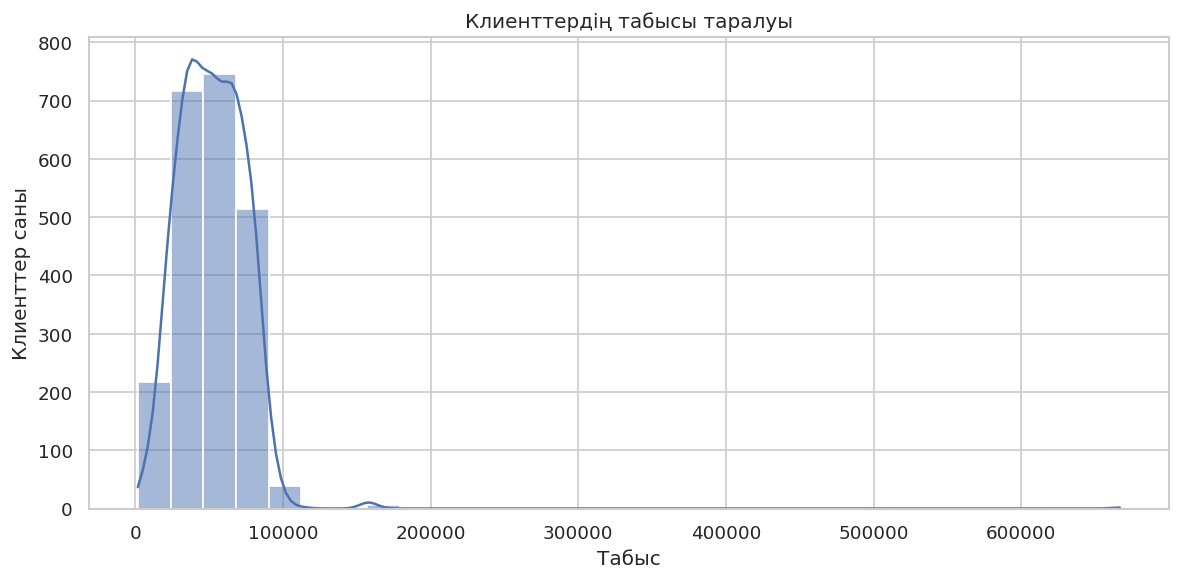

In [ ]:
# 2.4 Визуализация — Табыс таралуы
# клиенттердің көпшілігі қай табыс диапазонында?
fig, ax = plt.subplots(figsize=(10, 5))

# TODO 12: 'Income' бағаны үшін histplot сал (df['Income'], bins=30, kde=True)
sns.histplot(df['Income'], bins=30, kde=True, ax=ax)
ax.set_title('Клиенттердің табысы таралуы')
ax.set_xlabel('Табыс')
ax.set_ylabel('Клиенттер саны')
plt.tight_layout()
plt.show()

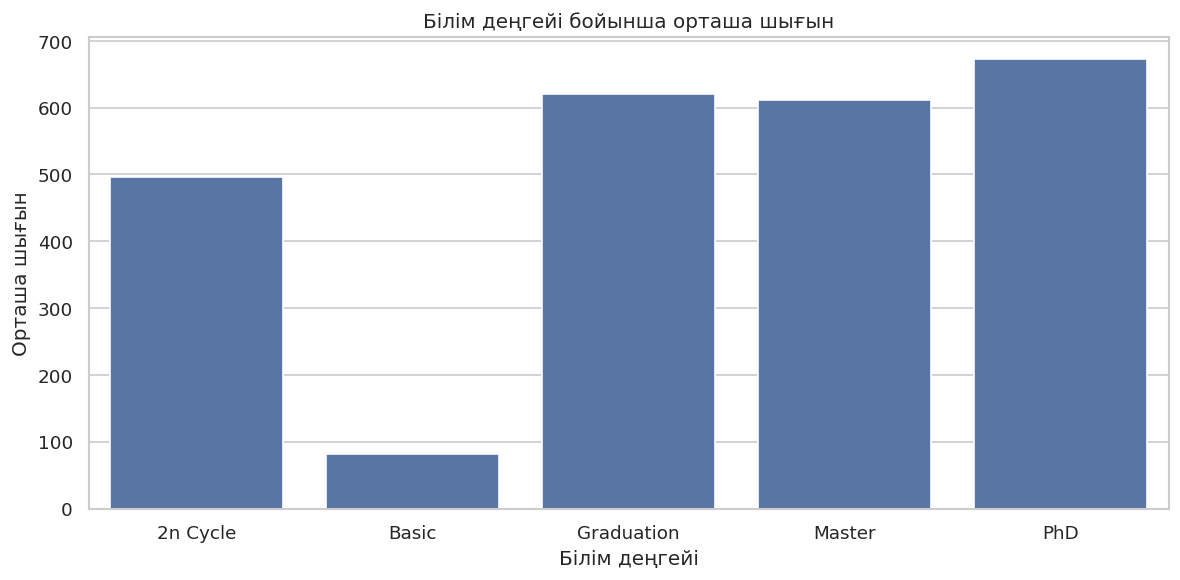

In [ ]:
# 2.5 Визуализация — Білім бойынша орташа шығын
fig, ax = plt.subplots(figsize=(10, 5))

# TODO 13: Білім деңгейі бойынша орташа жалпы шығынды barplot
df['MntTotal'] = (df['MntWines'] + df['MntFruits'] +
                  df['MntMeatProducts'] + df['MntFishProducts'] +
                  df['MntSweetProducts'] + df['MntGoldProds'])

df_edu_spent = df.groupby('Education')['MntTotal'].mean().reset_index()
#data=df_edu_spent, x='Education', y='MntTotal'
sns.barplot(data=df_edu_spent, x='Education', y='MntTotal', ax=ax)
ax.set_title('Білім деңгейі бойынша орташа шығын')
ax.set_xlabel('Білім деңгейі')
ax.set_ylabel('Орташа шығын')
plt.tight_layout()
plt.show()

>Descriptive нәтижесі:
>- Клиенттердің басым көпшілігі: Graduation 50,3%
>- Ең көп шығын жасайтын топ: PhD

# 3. DIAGNOSTIC ТАЛДАУ — "Неге кейбіреулер жауап береді?"


In [ ]:
from matplotlib.colors import Normalize
# 3.1 Жалпы жауап беру пайызы
print("\n--- Науқанға жауап беру пайызы ---")
# TODO 14: 'Response' бойынша value_counts(normalize=True)
print(df['Response'].value_counts(normalize=True))


--- Науқанға жауап беру пайызы ---
Response
0    0.850893
1    0.149107
Name: proportion, dtype: float64


In [ ]:
# 3.2 Жауап берген vs бермеген — табыс салыстыруы
print("\n--- Жауап бойынша орташа табыс ---")
# TODO 15: 'Response' бойынша топтап, 'Income' орташасы
print(df.groupby('Response')['Income'].mean())


--- Жауап бойынша орташа табыс ---
Response
0    50845.677597
1    60183.244012
Name: Income, dtype: float64


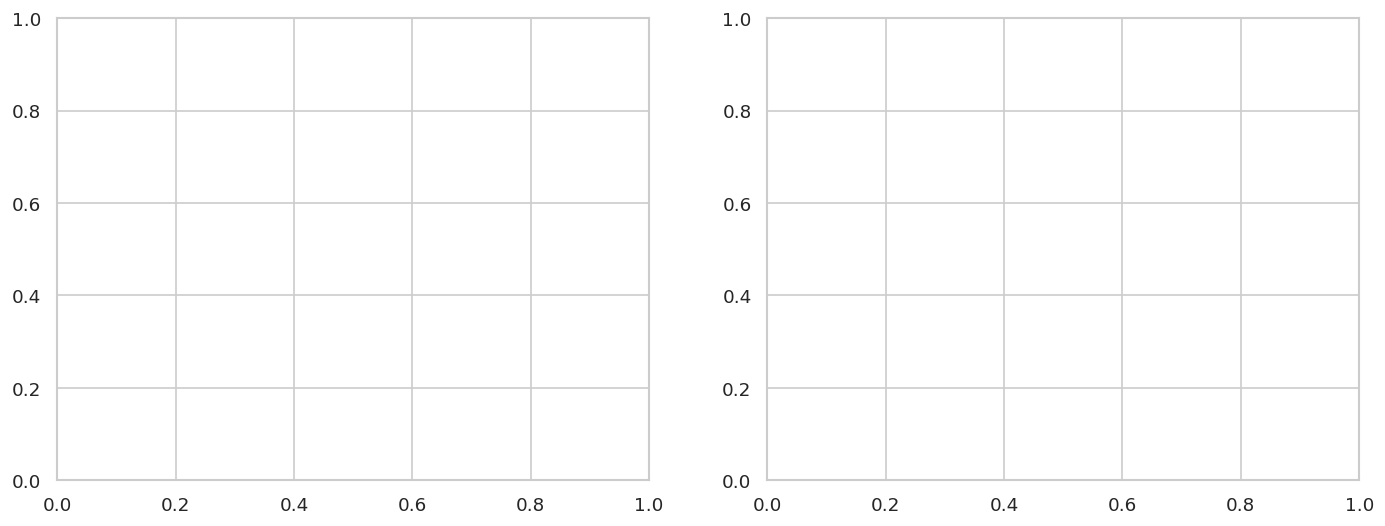

In [ ]:
# 3.3 Визуализация — Boxplot: табыс vs жауап
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

Text(0, 0.5, 'Табыс')

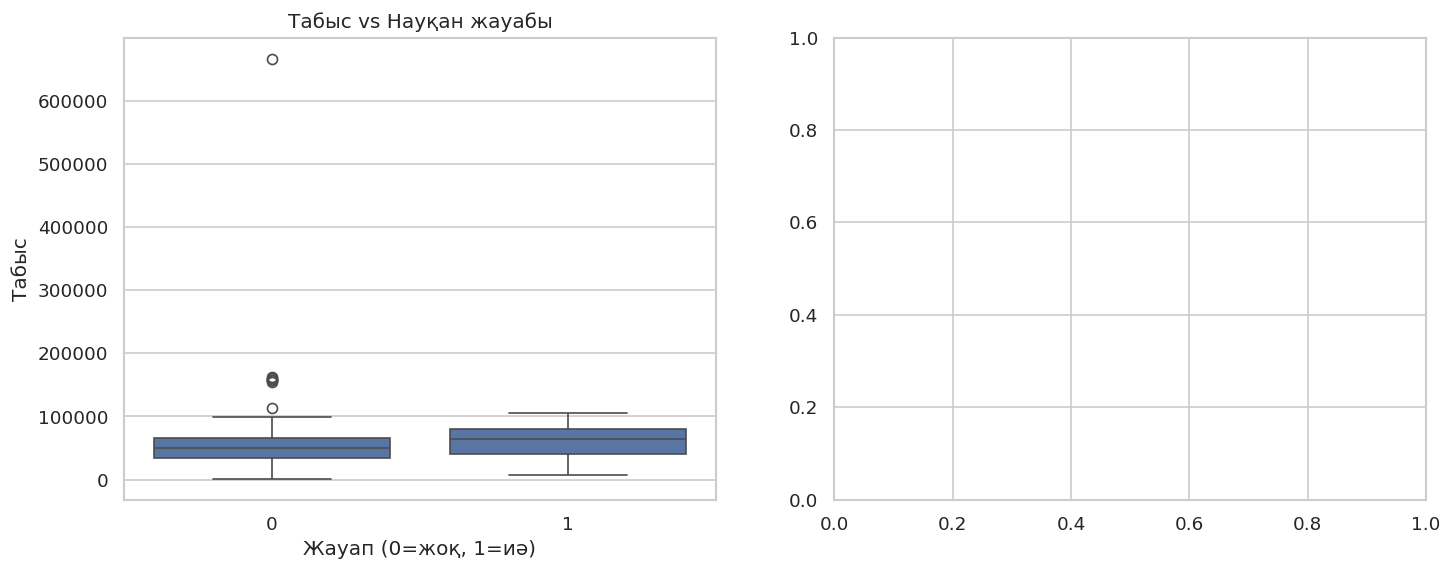

In [ ]:
# TODO 16: 'Response' бойынша 'Income' boxplot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, x='Response', y='Income', ax=axes[0])
axes[0].set_title('Табыс vs Науқан жауабы')
axes[0].set_xlabel('Жауап (0=жоқ, 1=иә)')
axes[0].set_ylabel('Табыс')

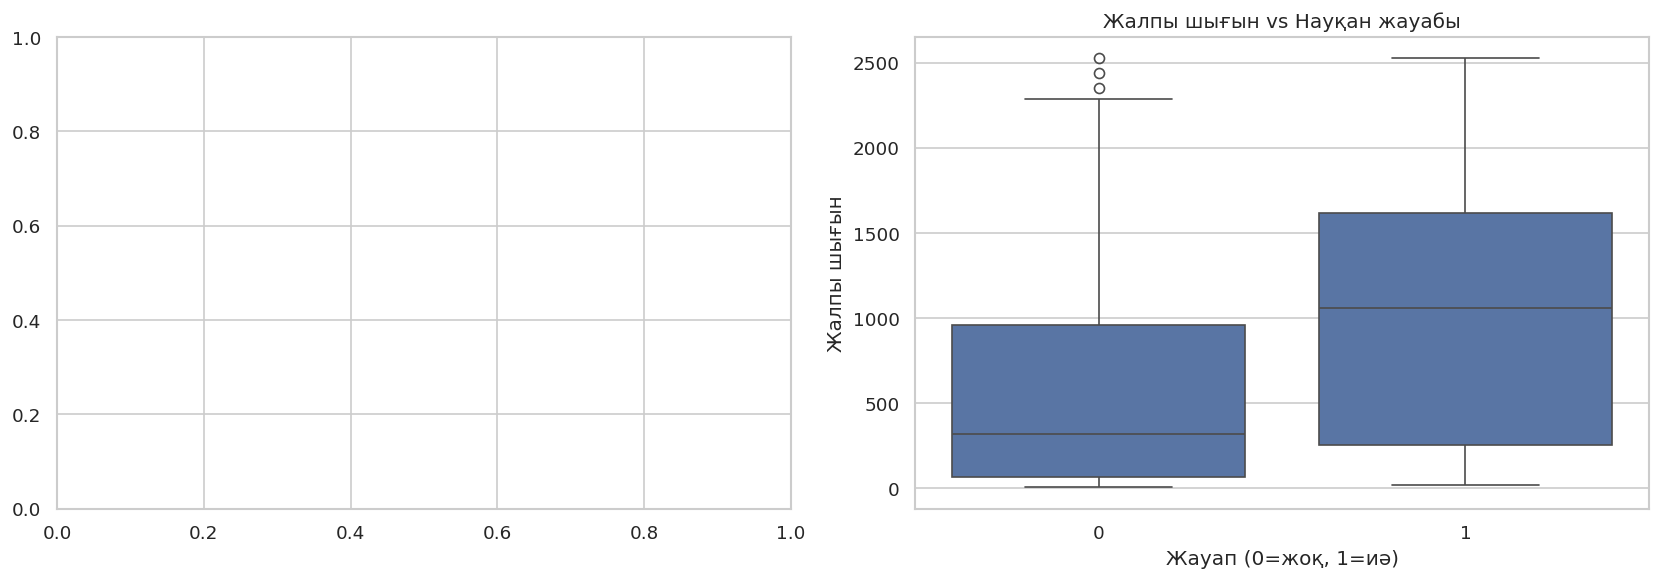

In [ ]:
# TODO 17: 'Response' бойынша 'MntTotal' boxplot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, x='Response', y='MntTotal', ax=axes[1])
axes[1].set_title('Жалпы шығын vs Науқан жауабы')
axes[1].set_xlabel('Жауап (0=жоқ, 1=иә)')
axes[1].set_ylabel('Жалпы шығын')

plt.tight_layout()
plt.show()

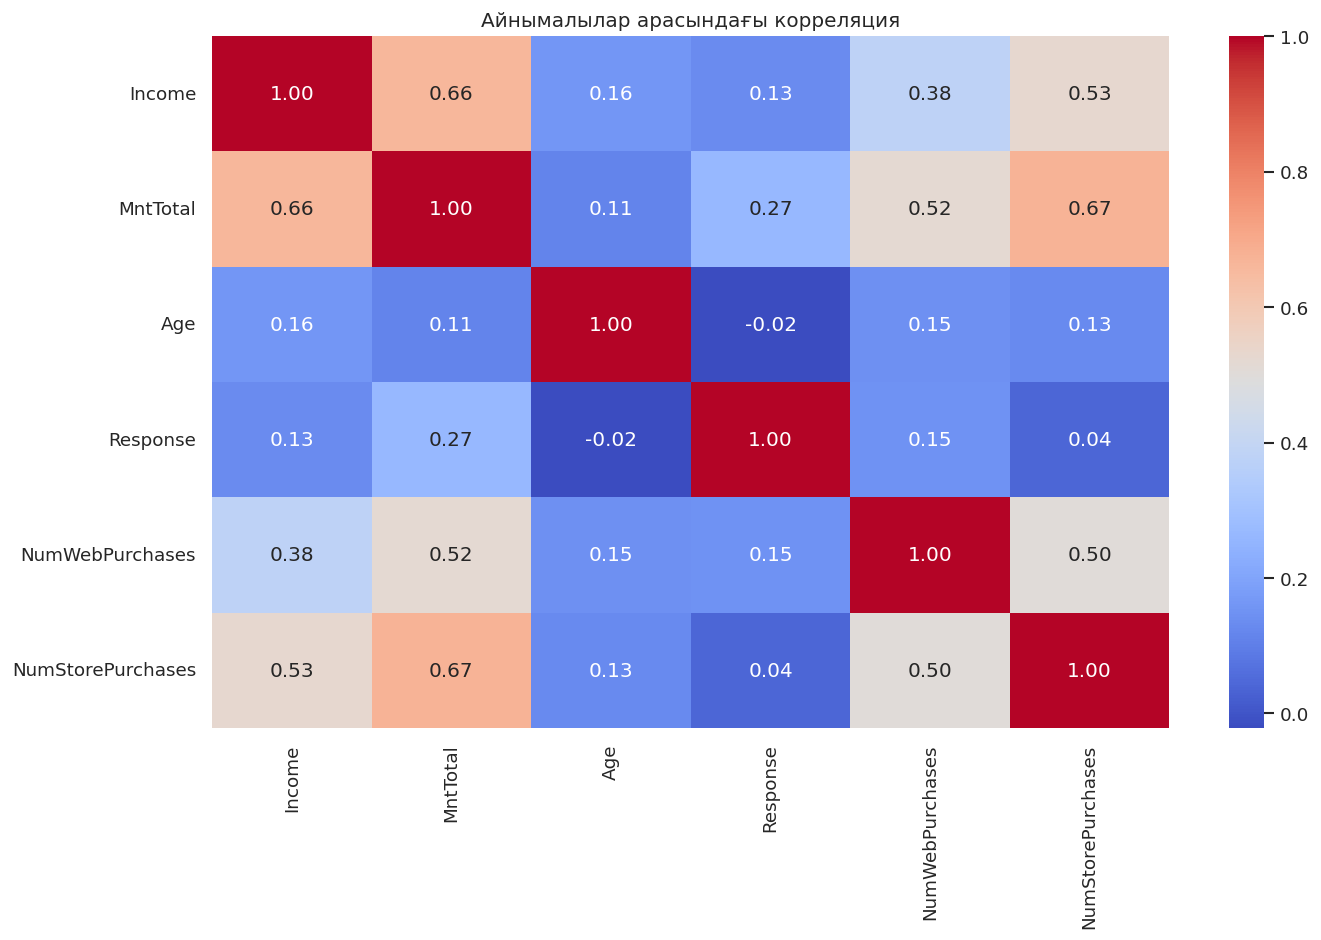

In [ ]:
# 3.4 Корреляция матрицасы
# байланысты бір уақытта көрсетеді.
# +1 = күшті оң байланыс, -1 = күшті теріс байланыс
df['Age'] = 2026 - df['Year_Birth']
fig, ax = plt.subplots(figsize=(12, 8))
# TODO 18: Корреляция
cols = ['Income', 'MntTotal', 'Age', 'Response',
        'NumWebPurchases', 'NumStorePurchases']
corr = df[cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', ax=ax)
ax.set_title('Айнымалылар арасындағы корреляция')
plt.tight_layout()
plt.show()



>Diagnostic нәтижесі:
>- Науқанға жауап беретін клиент портреті: Age ~ 56
                                          - income >60000
                                          - MntTotal: ~987
>- Ең күшті байланыс анықталды: MntTotal <-> NumStorePurchases                  (Клиенттер оффлайн магазинде көп шығындалады)
                                Income <-> MntTotal
(Табысы көп болса шығында көп болады)                                 

# 4. PREDICTIVE ТАЛДАУ — "Шығындар тренді қандай?"



Жылжымалы орташа (rolling average) шуды сүзіп,нақты бағытты көрсетеді. Егер тренд өсіп жатса — стратегия жұмыс істейді. Егер төмендесе — бірдеңе өзгерту керек.

In [ ]:
# Дата бағандарын шығару
df['year']  = df['Dt_Customer'].dt.year
df['month'] = df['Dt_Customer'].dt.month

In [ ]:
# TODO 19: Айлар бойынша жалпы шығынды топтаy
monthly = df.groupby(['year', 'month'])['MntTotal'].sum().reset_index()

In [ ]:
# TODO 20: 3 айлық скользящее среднее
monthly['rolling_3m'] = monthly['MntTotal'].rolling(3).mean()

In [ ]:
# TODO 21: Накопленный итог (cumsum)
monthly['cumulative'] = monthly['MntTotal'].cumsum()

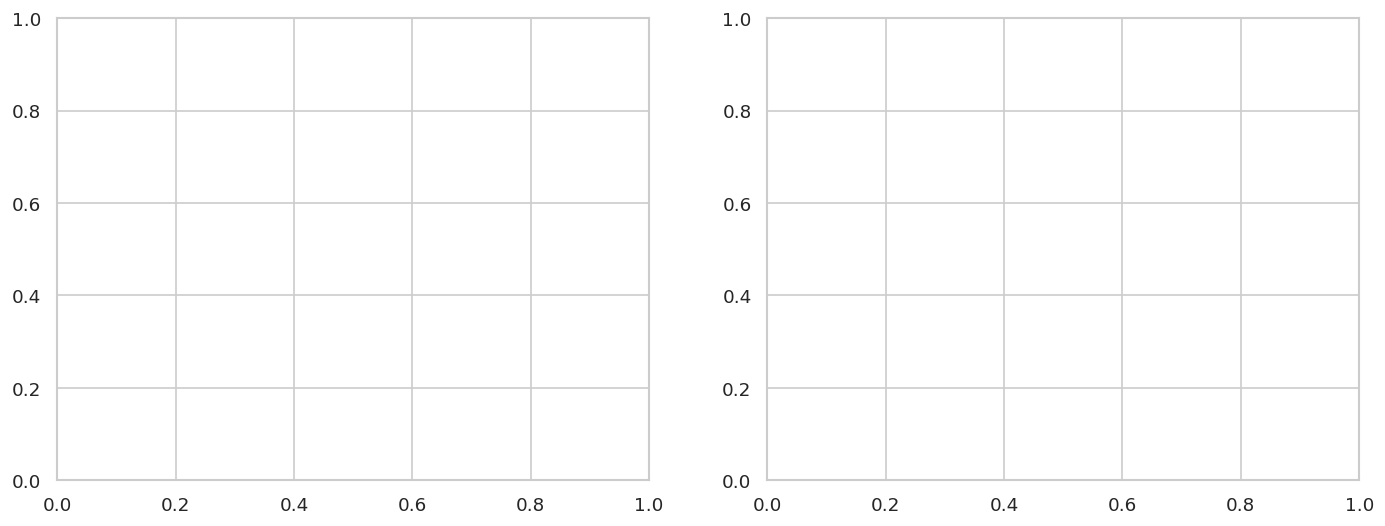

In [ ]:
# Визуализация — тренд
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

Text(0, 0.5, 'Жалпы шығын')

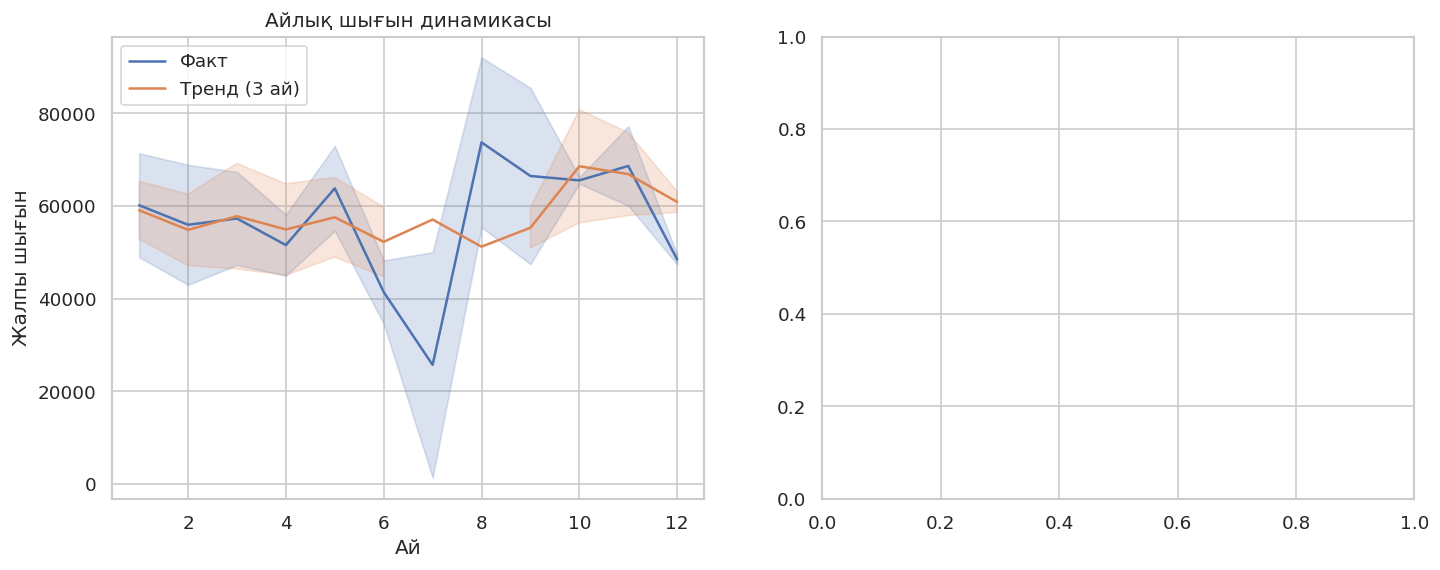

In [ ]:
# TODO 22: Айлық шығын + тренд lineplot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.lineplot(data=monthly, x='month', y='MntTotal',
             label='Факт', ax=axes[0])
sns.lineplot(data=monthly, x='month', y='rolling_3m',
             label='Тренд (3 ай)', ax=axes[0])
axes[0].set_title('Айлық шығын динамикасы')
axes[0].set_xlabel('Ай')
axes[0].set_ylabel('Жалпы шығын')

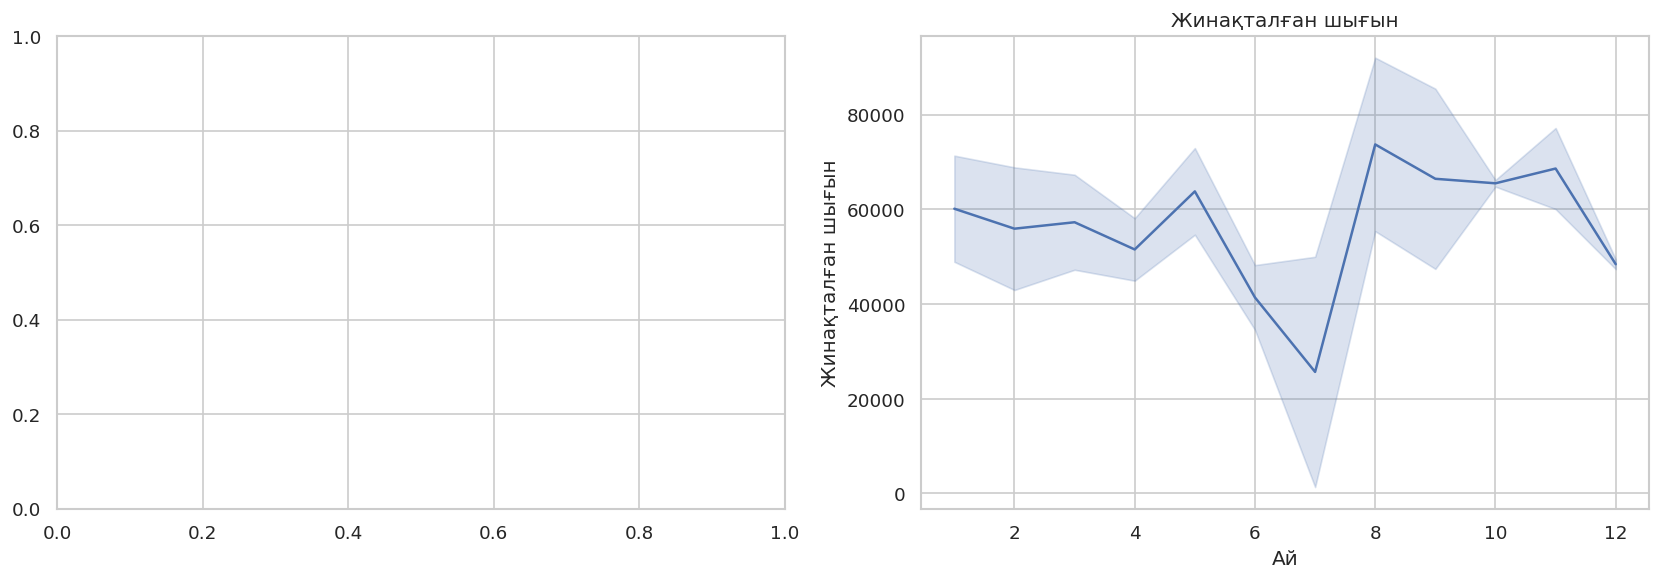

In [ ]:
# TODO 23: Накопленный итог lineplot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.lineplot(data=monthly, x='month', y='MntTotal', ax=axes[1])
axes[1].set_title('Жинақталған шығын')
axes[1].set_xlabel('Ай')
axes[1].set_ylabel('Жинақталған шығын')

plt.tight_layout()
plt.show()

>Predictive нәтижесі:
>- Жалпы тренд: Жалпы тренд бойынша шығындар салыстырмалы түрде тұрақты.3 айлық трендке қарасақ ұзақмерзімді тренде тұрақты байқауға болады,тіпті өсімде байқалады
>- Ең белсенді ай: Август

# 5. PRESCRIPTIVE ТАЛДАУ — "Не істеу керек?"



"Нәтиже тапты → Неге солай → Не істеу керек" — формуласы.

In [ ]:
# 5.1 Сатып алу арналары бойынша талдау
print("\n--- Арналар бойынша орташа шығын ---")
channels = ['NumWebPurchases', 'NumCatalogPurchases',
            'NumStorePurchases', 'NumDealsPurchases']
# TODO 24: Жауап берген (Response=1) клиенттердің арналар бойынша
#          орташа сатып алуы
responders = df[df['Response'] == 1]
print(responders[channels].mean().sort_values(ascending=False))


--- Арналар бойынша орташа шығын ---
NumStorePurchases      6.095808
NumWebPurchases        5.071856
NumCatalogPurchases    4.203593
NumDealsPurchases      2.335329
dtype: float64


In [ ]:
# 5.2 "Идеал клиент" портреті
print("\n--- Жауап берген клиенттің портреті ---")
# TODO 25: Response=1 клиенттердің орташа жасы, табысы, шығыны
print(responders[['Age','Income', 'MntTotal']].mean())


--- Жауап берген клиенттің портреті ---
Age            56.583832
Income      60183.244012
MntTotal      987.392216
dtype: float64


Text(0.5, 0.98, 'Маркетинг жобасы — Финалдық дашборд')

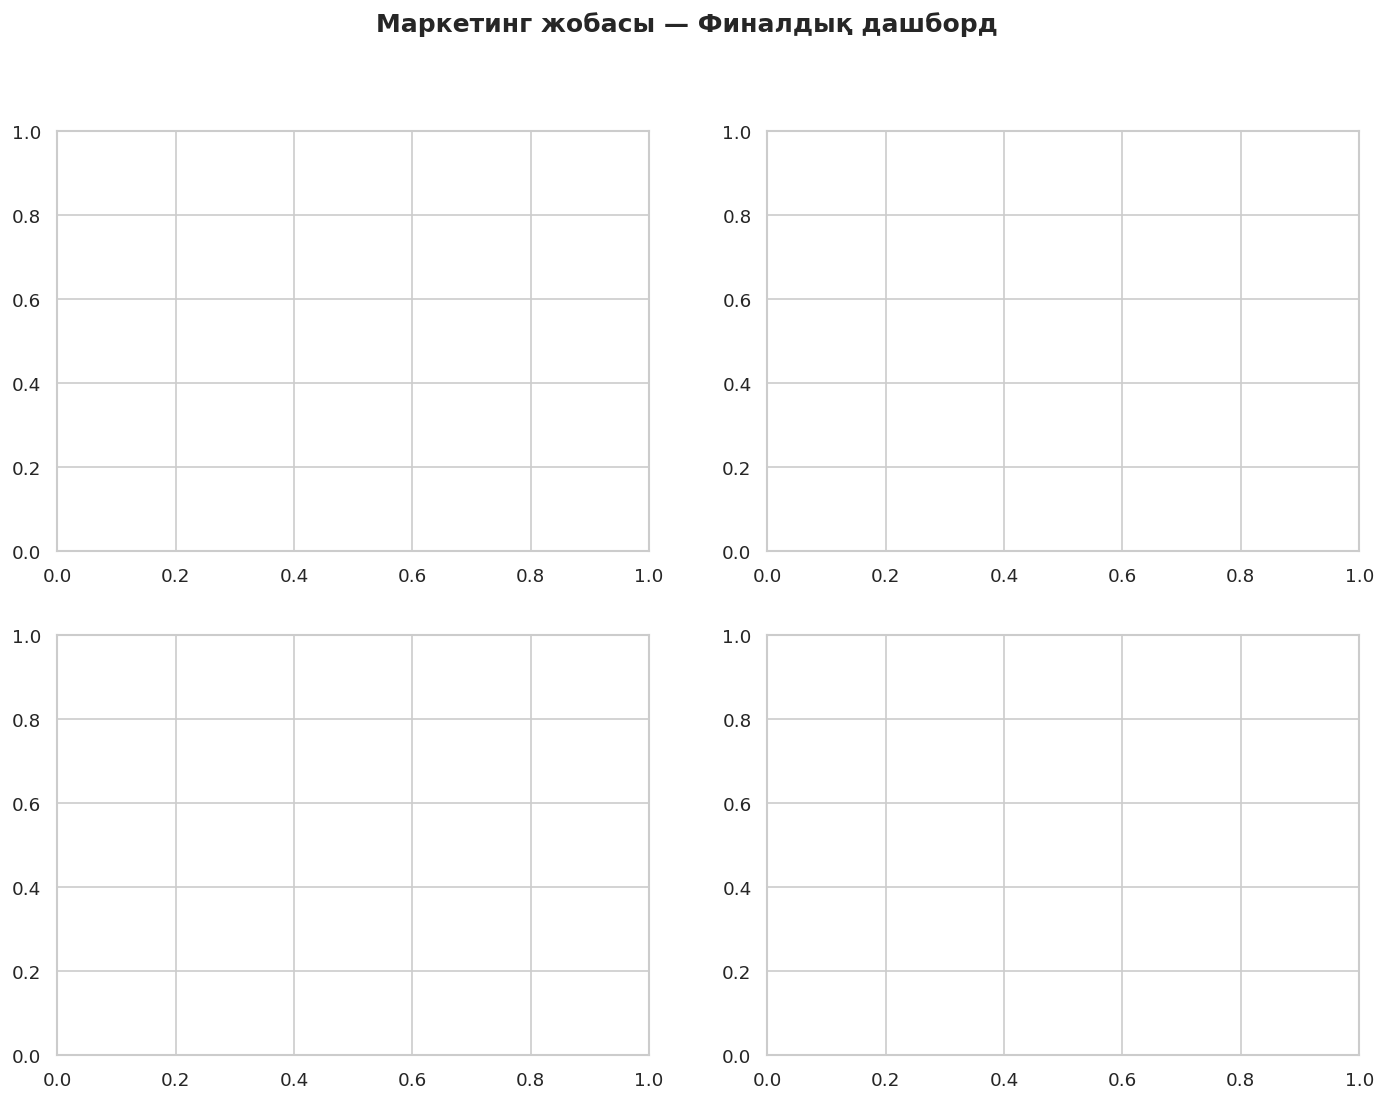

In [ ]:
# 5.3 Финалдық дашборд
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Маркетинг жобасы — Финалдық дашборд', fontsize=15, fontweight='bold')

Text(0.5, 1.0, 'Білім бойынша орташа шығын')

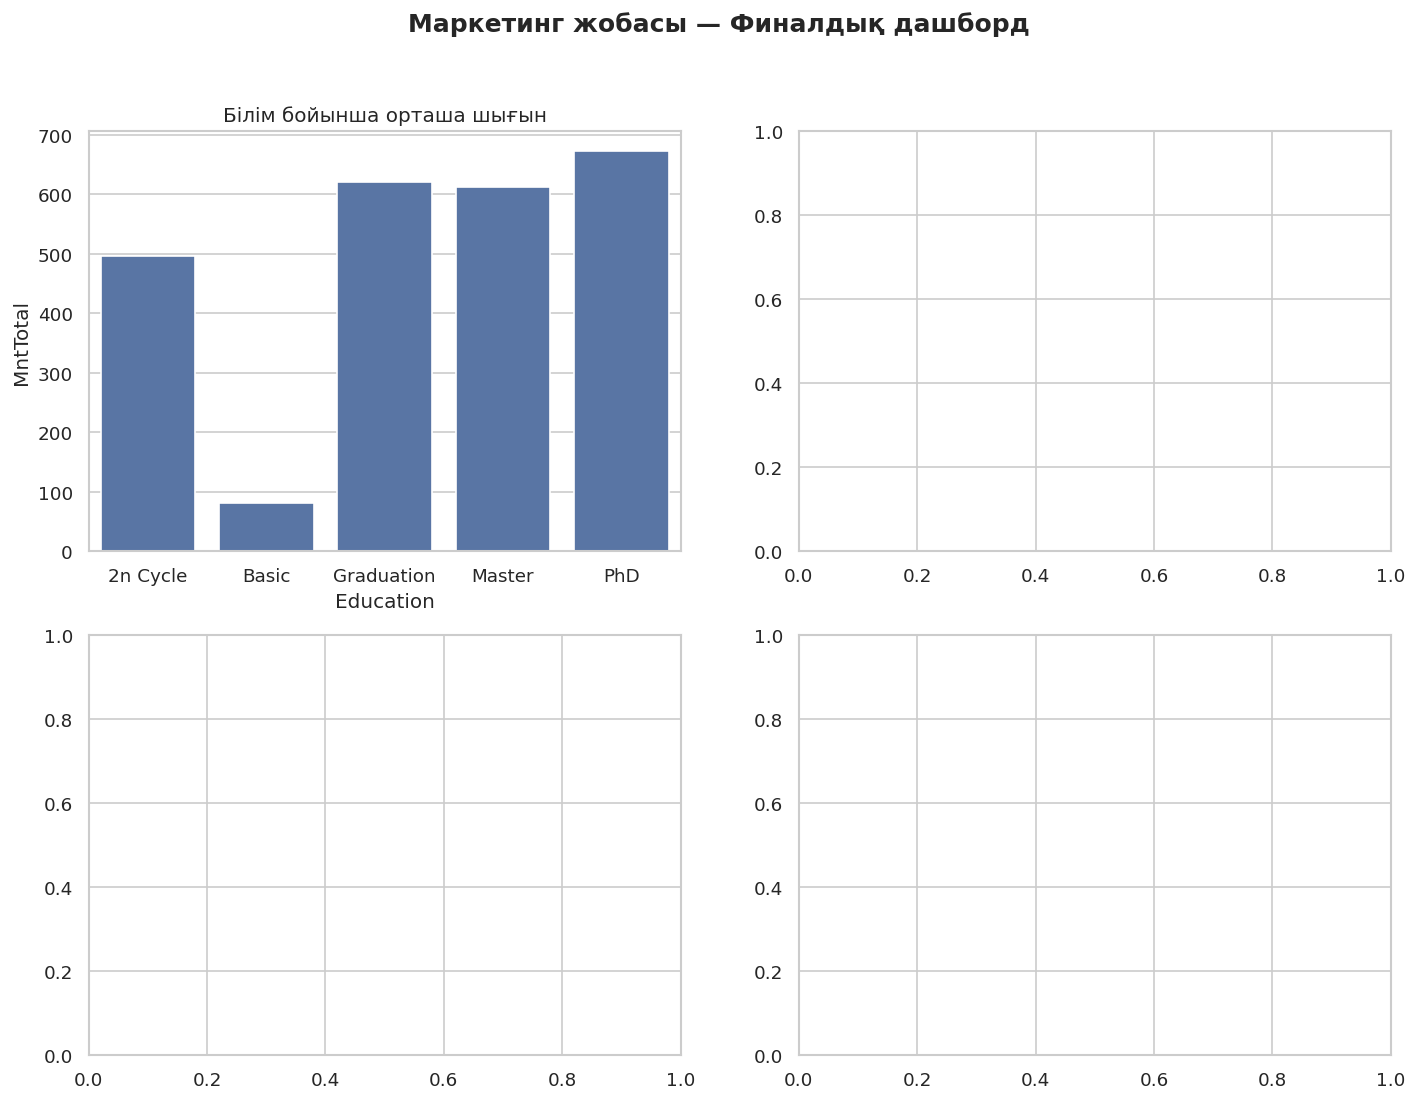

In [ ]:
# Граф 1: Білім бойынша шығын
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Маркетинг жобасы — Финалдық дашборд', fontsize=15, fontweight='bold')
sns.barplot(data=df_edu_spent, x='Education', y='MntTotal', ax=axes[0,0])
axes[0,0].set_title('Білім бойынша орташа шығын')

Text(0.5, 1.0, 'Айлық шығын динамикасы')

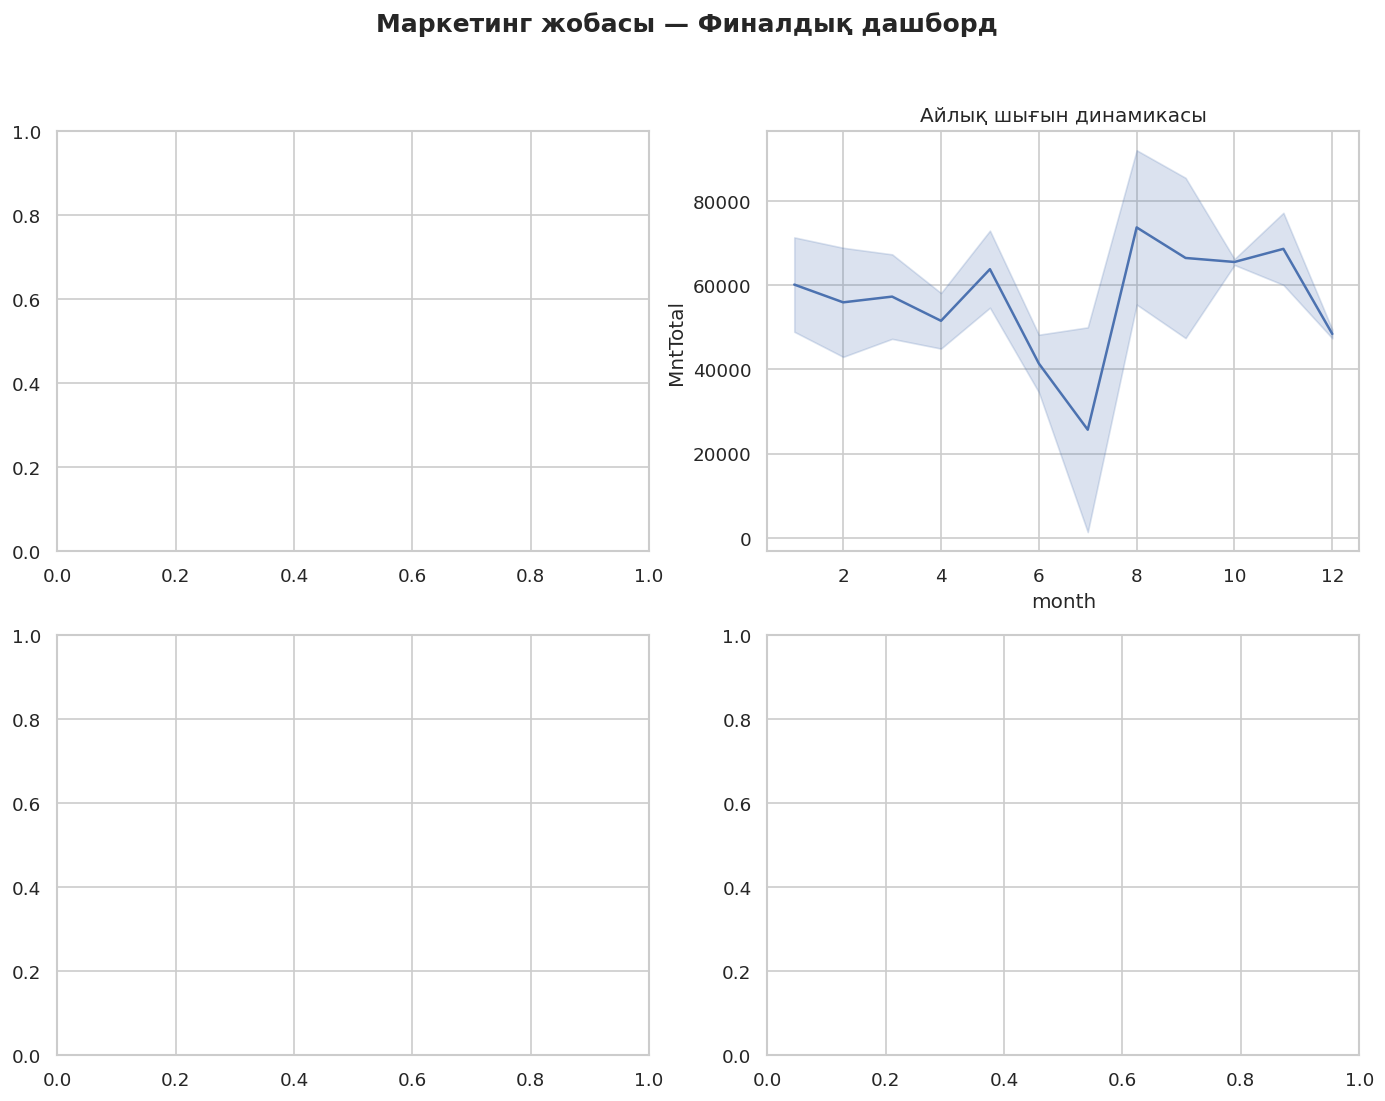

In [ ]:
# Граф 2: Тренд
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Маркетинг жобасы — Финалдық дашборд', fontsize=15, fontweight='bold')
sns.lineplot(data=monthly, x='month', y='MntTotal', ax=axes[0,1])
axes[0,1].set_title('Айлық шығын динамикасы')

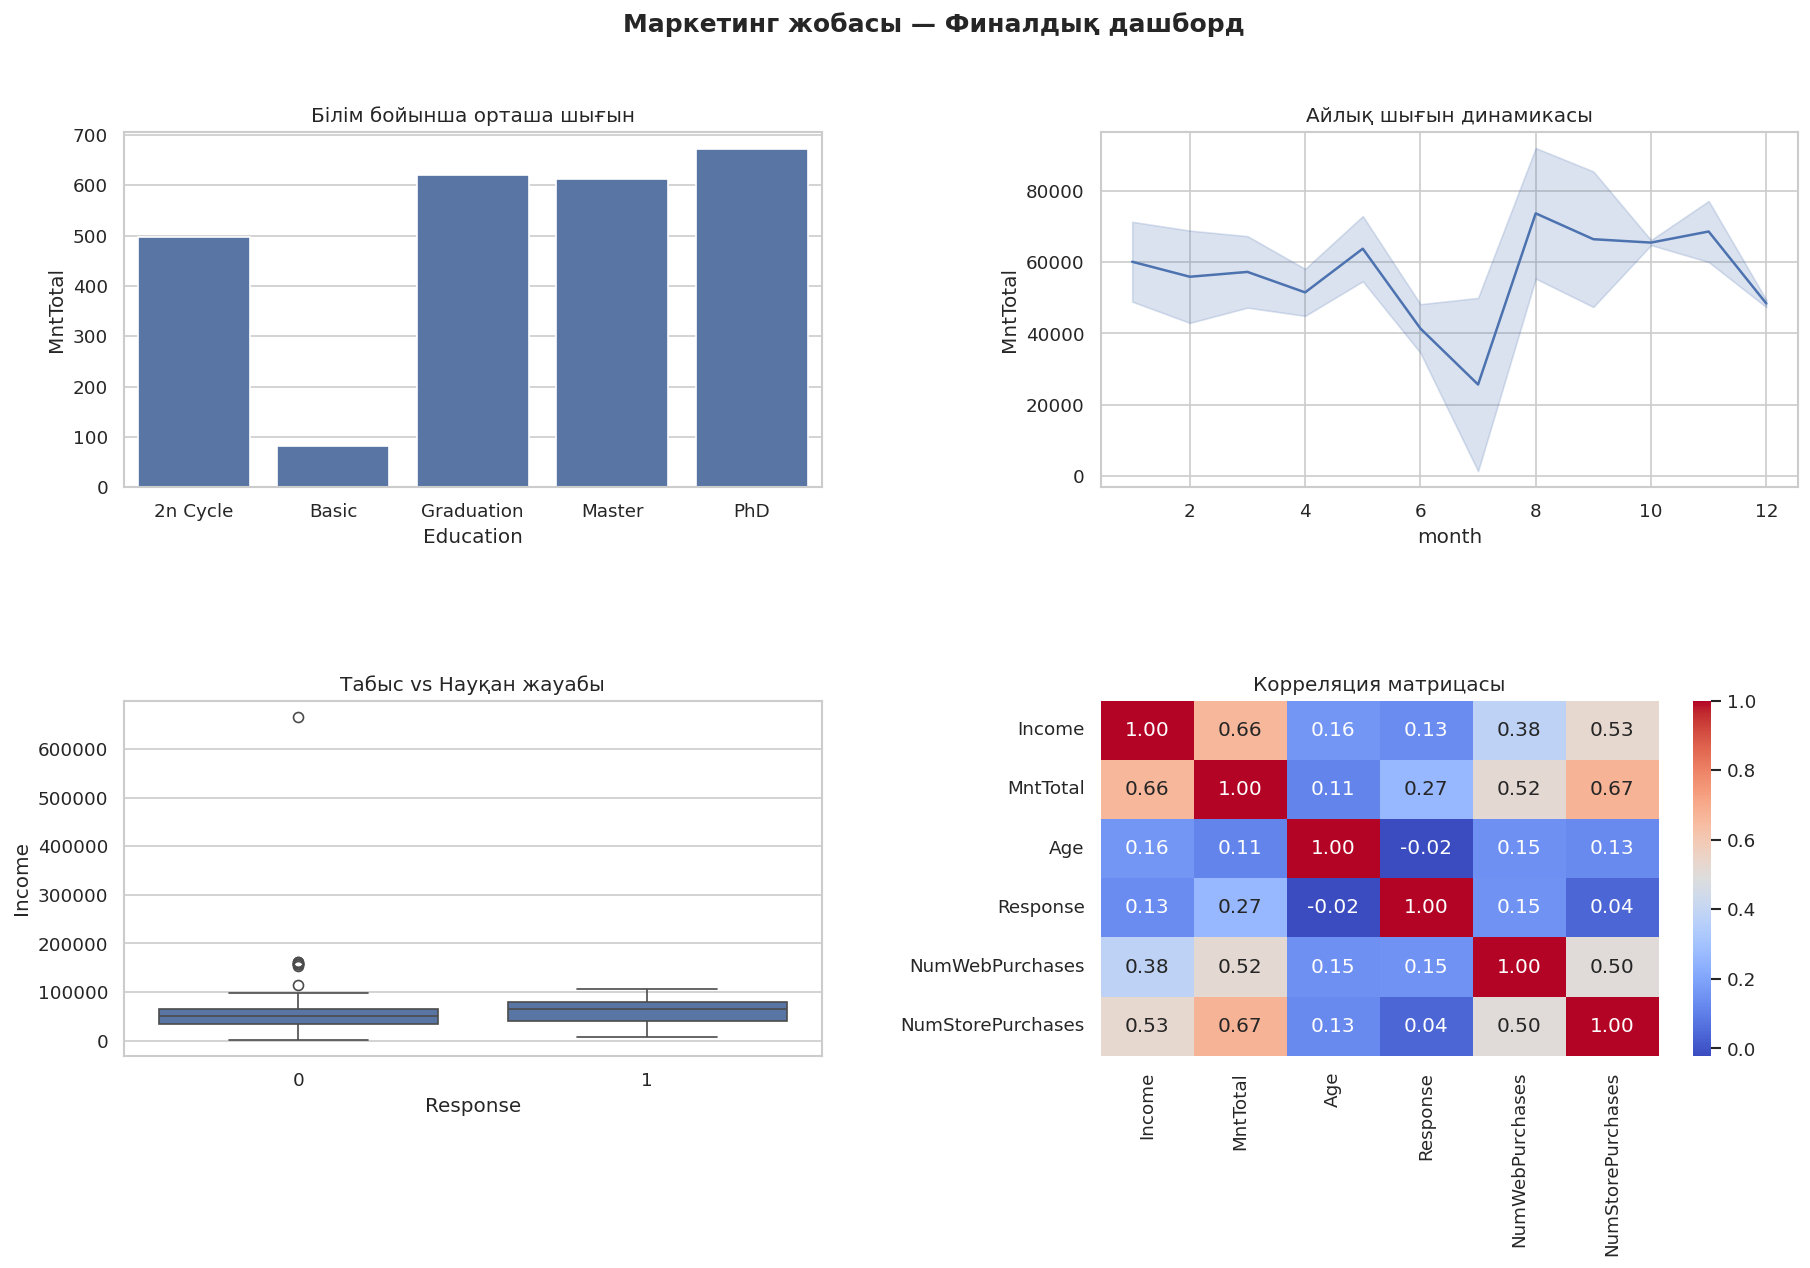

In [ ]:
# Граф 3: Табыс vs Жауап
# TODO 26: boxplot — Income vs Response
fig, axes = plt.subplots(2, 2, figsize=(18, 10))
fig.suptitle('Маркетинг жобасы — Финалдық дашборд', fontsize=15, fontweight='bold')
# Граф 1: Білім бойынша шығын
sns.barplot(data=df_edu_spent, x='Education', y='MntTotal', ax=axes[0,0])
axes[0,0].set_title('Білім бойынша орташа шығын')
# Граф 2: Тренд
sns.lineplot(data=monthly, x='month', y='MntTotal', ax=axes[0,1])
axes[0,1].set_title('Айлық шығын динамикасы')
# Граф 4: Корреляция
df['Age'] = 2026 - df['Year_Birth']
sns.heatmap(df[cols].corr(), annot=True, cmap='coolwarm',
            fmt='.2f', ax=axes[1,1])
axes[1,1].set_title('Корреляция матрицасы')
sns.boxplot(data=df, x='Response', y='Income', ax=axes[1,0])
axes[1,0].set_title('Табыс vs Науқан жауабы')
plt.subplots_adjust(hspace=0.6, wspace=0.4)


# 6. ҚОРЫТЫНДЫ ҰСЫНЫСТАР (өз сөзіңмен толтыр)

>ІСКЕРЛІК ҰСЫНЫСТАР
>1. Таргет аудитория: Орташа табысы 60000 жоғары
                    Жас шамасы ~56
                    Білімі: PhD және Graduation(доходы және расходы көп)
>2. Ең тиімді арна: Оффлайн магазин corr=0,67
>3. Ең белсенді кезең: Август
>4. Ұсыныс: Барлық клиентке бірдей жарнама емес
            Клиенттерді категорияға бөліп персонализированный предложения жасау керек.
            Мысалы:
            
            Доходы көп клиенттерге -> премиальный товар
            
            Көп тапсырыс жасамайтын клиенттерге -> Келесі покупкаға купон
            
            Жаңа клиентке бірінші сатып алуға жеңілдіктер ұсыну    